# Notebook Crash-Sim: OpenRadioss Simulation Dataset Generation

**Series:** End-to-End AI for Science — Crash Simulation Track  
**Position in workflow:** Runs **before** Notebook_Crash0 (Data Preprocessing)

```
[This notebook]                    [Notebook_Crash0]              [Notebook_Crash1/2]
OpenRadioss  →  d3plot files  →  Curator ETL  →  Zarr stores  →  GeoTransolver training
```

---

## What This Notebook Does

Generates a **parameterised dataset of crash simulations** using [OpenRadioss](https://openradioss.org),  
the open-source structural dynamics solver, and converts the output into the  
`d3plot` file layout that `Notebook_Crash0-Data-Preprocessing` expects.

Two simulation cases are covered:

| Case | Physical Setup | DoE Size | Varied Parameters |
|------|---------------|----------|-------------------|
| **Bumper Beam** | Front-impact bumper on rigid wall | 135 runs | geometry scale, velocity, thickness, wall position |
| **Drop Test** | Cell-phone drop onto flat plane | 192 runs | material Young's modulus, wall orientation |

Both cases share the same 4-step pipeline:  
`Starter` → `Engine` → `anim-to-VTK` → `anim-to-d3plot` → `rename` → `global_features.json`

---

## Prerequisites Before Running

- Linux x86-64 system (Ubuntu 22.04 recommended)
- `gfortran` 11+, `cmake` 3.22+, `OpenMPI` 4.1+
- ~20 GB disk space for full bumper beam dataset (135 runs)
- Multi-core CPU (8+ cores recommended for parallel simulation)
- Python 3.10+

## Series Overview

Where this notebook sits in the crash simulation series:

<img src="fig/series_overview_simgen.svg" alt="Crash series overview" width="50%">

<details>
<summary>Mermaid source (editable)</summary>

```mermaid
flowchart LR
    SG[<b>Notebook Crash-Sim</b><br/>OpenRadioss SimGen<br/><i>generate d3plot dataset</i>]
    C0[<b>Notebook Crash-0</b><br/>Data Preprocessing<br/><i>d3plot to Zarr ETL</i>]
    C1[<b>Notebook Crash-1</b><br/>Architecture and Concepts<br/><i>GeoTransolver theory</i>]
    C2[<b>Notebook Crash-2</b><br/>Training and Comparison<br/><i>train and evaluate</i>]

    SG -->|"d3plot files"| C0
    C0 -->|"Zarr stores"| C2
    C1 -.->|"concepts"| C2

    style SG fill:#1a6b3a,color:#fff,stroke:#0d4a28,stroke-width:3px
```

</details>

> **You are here:** Notebook Crash-Sim — the data generation stage.


## Pipeline Overview

This notebook runs a 6-step pipeline for each simulation case. The diagram below shows the full flow from `.rad` templates to the `d3plot` layout expected by `Notebook_Crash0`.


<img src="fig/simgen_pipeline.svg" alt="OpenRadioss dataset generation pipeline" width="50%">

<details>
<summary>Mermaid source (editable)</summary>

```mermaid
flowchart TD
    T[(".rad Templates<br/>starter + engine decks")] --> DOE

    DOE[<b>Step 0 · generate_dataset.py</b><br/>Cartesian product of DoE parameters<br/>135 Bumper Beam runs / 192 Drop Test runs]

    DOE -->|"one folder per parameter set"| RUNS

    RUNS[("dataset/run0001/ ... run0135/<br/>mutated .rad decks + run.json")]

    RUNS --> S

    S[<b>Step 1 · Starter</b><br/>starter_linux64_gf -i *_0000.rad -nt 8<br/>parses model, builds restart file]

    S -->|"*_0001.rst"| E

    E[<b>Step 2 · Engine</b><br/>engine_linux64_gf -i *_0001.rad<br/>explicit time integration]

    E -->|"A001 A002 ... A051 ANIM frames"| V
    E -->|"A001 A002 ... A051 ANIM frames"| D

    V[<b>Step 3 · anim_to_vtk</b><br/>A001 to A001.vtk<br/>displacement, von Mises, plastic strain]

    D[<b>Step 4 · vortex_radioss</b><br/>animtod3plot.readAndConvert<br/>ANIM to LS-DYNA d3plot]

    D -->|"Bumper_Beam_AP_meshed.d3plot*"| R

    R[<b>Step 5 · rename_d3plot.py</b><br/>strip mesh prefix<br/>d3plot, d3plot01, ... d3plot51]

    R --> GF

    GF[<b>Step 6 · restructure_global_features.py</b><br/>collect per-run DoE parameters<br/>global_features.json]

    GF --> OUT

    OUT[("data/bumperbeam_openradioss/<br/>RAW_DATA/Run0001/d3plot*<br/>+ global_features.json")]

    V -.->|"visualization only"| VIZ
    VIZ[<b>Section 13 · Visualize</b><br/>displacement grid + animated GIF]

    OUT --> NB0
    NB0[<b>Notebook Crash-0</b><br/>Curator ETL to Zarr]

    style T fill:#4a7fb5,color:#fff
    style DOE fill:#6a5acd,color:#fff
    style GF fill:#6a5acd,color:#fff
    style OUT fill:#1a6b3a,color:#fff
    style NB0 fill:#1a6b3a,color:#fff
    style VIZ fill:#e07b00,color:#fff
```

</details>

**Step-by-step summary:**

| Step | Script / Binary | Input | Output |
|:----:|-----------------|-------|--------|
| 0 | `generate_dataset.py` | templates + DoE dict | `run*/` folders with mutated decks |
| 1 | `starter_linux64_gf` | `*_0000.rad` | `*_0001.rst` restart file |
| 2 | `engine_linux64_gf` | `*_0001.rad` + `.rst` | `A001 … A051` ANIM frames |
| 3 | `anim_to_vtk_linux64_gf` | `A0xx` | `A0xx.vtk` (for visualization) |
| 4 | `vortex_radioss` | `A0xx` | `*.d3plot`, `*.d3plot01` … |
| 5 | `rename_d3plot.py` | `*.d3plot*` | `d3plot`, `d3plot01` … |
| 6 | `restructure_global_features.py` | `run*/run*.json` | `global_features.json` |


## Section 1 — Installing OpenRadioss

OpenRadioss is a free, open-source structural dynamics solver released by Altair.  
It is the open-source version of Radioss and uses the same `.rad` input deck format.

> **Recommended: download pre-built binaries.** Building from source takes 20–40 min  
> and requires matching compiler versions. The pre-built Linux release is a single ZIP  
> that works on Ubuntu 20.04+, Rocky Linux 8+, and RHEL 8+.

---

### Option A — Download Pre-built Binaries (Recommended)

```bash
# 1. Download the latest Linux x86-64 release (~76 MB)
wget https://github.com/OpenRadioss/OpenRadioss/releases/download/latest-20260615/OpenRadioss_linux64.zip

# 2. Unzip — the zip extracts to /opt/OpenRadioss/
unzip OpenRadioss_linux64.zip -d /opt/

# 3. Rename to the path expected by this notebook
mv /opt/OpenRadioss /opt/OpenRadioss_linux64

# Result:
#   /opt/OpenRadioss_linux64/exec/starter_linux64_gf
#   /opt/OpenRadioss_linux64/exec/engine_linux64_gf
#   /opt/OpenRadioss_linux64/exec/anim_to_vtk_linux64_gf
#   /opt/OpenRadioss_linux64/extlib/
#   /opt/OpenRadioss_linux64/hm_cfg_files/

# 4. Set the root path (add to ~/.bashrc to persist)
export OPENRADIOSS_ROOT=/opt/OpenRadioss_linux64
```

Check the [releases page](https://github.com/OpenRadioss/OpenRadioss/releases)  
for the latest tag — substitute `latest-20260615` with the current tag if needed.

---

### Option B — Build from Source

OpenRadioss uses its own `build_script.sh` — **do not call `cmake` directly**.  
The build script handles all architecture flags, library linking, and binary placement.

#### System prerequisites (Ubuntu)

```bash
sudo apt-get update && sudo apt-get install -y \
    build-essential gfortran cmake perl \
    python3 python-is-python3 git git-lfs \
    libasan6 libubsan1
```

#### Clone (requires git-lfs for extlib binaries)

```bash
git lfs install
git clone https://github.com/OpenRadioss/OpenRadioss.git
export OPENRADIOSS_ROOT=$(pwd)/OpenRadioss
```

#### Build Starter

```bash
cd $OPENRADIOSS_ROOT/starter
./build_script.sh -arch=linux64_gf -release -nt=$(nproc)
# Binary output: $OPENRADIOSS_ROOT/exec/starter_linux64_gf
```

#### Build Engine (SMP / OpenMP only — no MPI needed for dataset gen)

```bash
cd $OPENRADIOSS_ROOT/engine
./build_script.sh -arch=linux64_gf -release -nt=$(nproc)
# Binary output: $OPENRADIOSS_ROOT/exec/engine_linux64_gf
```

#### Build anim_to_vtk (separate Tools repository)

`anim_to_vtk` is **not** in the main OpenRadioss repo and does **not** use cmake.  
It lives in [OpenRadioss/Tools](https://github.com/OpenRadioss/Tools) and builds  
with a plain `g++` command via `build.bash`:

```bash
git clone https://github.com/OpenRadioss/Tools.git
cd Tools/output_converters/anim_to_vtk/linux64

# build.bash compiles ../src/anim_to_vtk.cpp and copies the binary to
# ../../../exec/ relative to the Tools clone.
# Run it from inside linux64/ so the relative path resolves correctly:
./build.bash
# Binary output: Tools/exec/anim_to_vtk_linux64_gf

# Copy to your OpenRadioss exec/ directory
cp ../../../exec/anim_to_vtk_linux64_gf $OPENRADIOSS_ROOT/exec/
```

If the `../../../exec/` path doesn't match your layout, compile directly:

```bash
g++ -DLINUX -o $OPENRADIOSS_ROOT/exec/anim_to_vtk_linux64_gf ../src/anim_to_vtk.cpp
```

> **Why the cmake errors happened:** The main OpenRadioss CMakeLists.txt is a  
> project-level wrapper intended to be called from the root, not from  
> `starter/` or `engine/` subdirectories. Direct `cmake -S . -B build/`  
> inside those directories triggers CMake policy CMP0175 errors in CMake 3.28+.  
> Always use `build_script.sh` inside the `starter/` or `engine/` directories.

---

### Set Environment Variables

After either option, set these before running simulations:

```bash
export OPENRADIOSS_ROOT=/opt/OpenRadioss_linux64   # or your build path
export RAD_CFG_PATH=$OPENRADIOSS_ROOT/hm_cfg_files
export OMP_STACKSIZE=400m
export OMP_NUM_THREADS=8
export LD_LIBRARY_PATH=$OPENRADIOSS_ROOT/extlib/hm_reader/linux64:$LD_LIBRARY_PATH

# Optional: add exec/ to PATH so you can call the executables directly
export PATH=$OPENRADIOSS_ROOT/exec:$PATH
```

### 1.1 Verify the Installation

In [2]:
import os, subprocess
from pathlib import Path

# ── Set OPENRADIOSS_ROOT ───────────────────────────────────────────────────────
# The pre-built OpenRadioss binary is installed at /opt/OpenRadioss_linux64_linux64
# (copied there in Section 1).  Change this only if you built from source.
#
OPENRADIOSS_ROOT = Path(os.environ.get("OPENRADIOSS_ROOT", "/opt/OpenRadioss_linux64"))

# Uncomment to override:
# OPENRADIOSS_ROOT = Path("/opt/OpenRadioss_linux64_linux64")

print(f"OPENRADIOSS_ROOT = {OPENRADIOSS_ROOT}  (exists={OPENRADIOSS_ROOT.exists()})")
print()

executables = {
    "Starter":     OPENRADIOSS_ROOT / "exec" / "starter_linux64_gf",
    "Engine":      OPENRADIOSS_ROOT / "exec" / "engine_linux64_gf",
    "Anim to VTK": OPENRADIOSS_ROOT / "exec" / "anim_to_vtk_linux64_gf",
}
libraries = {
    "libh3dwriter.so  (H3D output)": OPENRADIOSS_ROOT / "extlib" / "h3d" / "lib" / "linux64" / "libh3dwriter.so",
    "libhm_reader.so  (HM reader)":  OPENRADIOSS_ROOT / "extlib" / "hm_reader" / "linux64" / "libhm_reader.so",
}

print("Executables:")
all_exe_ok = True
for name, path in executables.items():
    ok = path.exists()
    if not ok: all_exe_ok = False
    print(f"  {'FOUND' if ok else 'MISSING':8s}  {name:15s}  {path}")

print()
print("Required shared libraries:")
all_lib_ok = True
for name, path in libraries.items():
    ok = path.exists()
    if not ok: all_lib_ok = False
    print(f"  {'FOUND' if ok else 'MISSING':8s}  {name}  {path}")

print()
if not all_lib_ok:
    print("WARNING: libh3dwriter.so missing — engine will fail with 'H3D EXTERNAL LIBRARY NOT FOUND'.")
else:
    print("All libraries found.")

print()
if all_exe_ok:
    result = subprocess.run([str(executables["Starter"]), "-h"],
                            capture_output=True, text=True, timeout=10)
    first_line = (result.stdout + result.stderr).strip().split("\n")[0]
    print(f"Starter check: {first_line[:80]}")
    print("OpenRadioss installation verified.")
else:
    print("Some executables missing — check OPENRADIOSS_ROOT.")


OPENRADIOSS_ROOT = /opt/OpenRadioss_linux64  (exists=True)

Executables:
  FOUND     Starter          /opt/OpenRadioss_linux64/exec/starter_linux64_gf
  FOUND     Engine           /opt/OpenRadioss_linux64/exec/engine_linux64_gf
  FOUND     Anim to VTK      /opt/OpenRadioss_linux64/exec/anim_to_vtk_linux64_gf

Required shared libraries:
  FOUND     libh3dwriter.so  (H3D output)  /opt/OpenRadioss_linux64/extlib/h3d/lib/linux64/libh3dwriter.so
  MISSING   libhm_reader.so  (HM reader)  /opt/OpenRadioss_linux64/extlib/hm_reader/linux64/libhm_reader.so


Starter check: /opt/OpenRadioss_linux64/exec/starter_linux64_gf: error while loading shared lib
OpenRadioss installation verified.


## Section 2 — Python Dependencies

Two packages are needed:

| Package | Purpose | Install |
|---------|---------|---------|
| `lasso-python` | Reads LS-DYNA `d3plot` binary files | PyPI |
| `vortex-radioss` | Converts OpenRadioss `.anim` files → `d3plot` | GitHub only (not on PyPI) |

> **Expected warnings during install — all harmless:**
> - `psutil>=6.0.0` conflict with `nvidia-resiliency-ext` → does not affect lasso or vortex_radioss
> - `numpy<2.3` conflict with `numba` → lasso and vortex_radioss work fine with numpy 2.x
> - "Running pip as root" warning → expected in container environments
>
> The cell will print `OK lasso` and `OK vortex_radioss` at the end if both installed correctly.
> Those two lines are all that matters.


In [3]:
# ── Install Python dependencies ───────────────────────────────────────────────
# vortex-radioss is NOT on PyPI — must install from GitHub
!pip install lasso-python --quiet
!pip install git+https://github.com/Vortex-CAE/Vortex-Radioss.git --quiet

# ── Verify ─────────────────────────────────────────────────────────────────────
# Ignore any dependency conflict warnings above — they do not affect these packages.
# The two OK lines below are the only thing that matters.
import importlib
all_ok = True
for pkg in ["lasso", "vortex_radioss"]:
    try:
        m = importlib.import_module(pkg)
        print(f"  OK  {pkg}  version={getattr(m, '__version__', '?')}")
    except ImportError:
        print(f"  MISSING  {pkg}  ← installation failed")
        all_ok = False

print()
if all_ok:
    print("Both packages installed. Proceed to Section 3.")
else:
    print("One or more packages missing — check the pip output above for errors.")


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nvidia-resiliency-ext 0.5.0 requires psutil>=6.0.0, but you have psutil 5.9.8 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.5.1 which is incompatible.
  DEPRECATION: Setting PIP_CONSTRAINT will not affect build constraints in the future, pip 26.2 will enforce this behaviour change. A possible replacement is to specify build constraints using --build-constraint or PIP_BUILD_CONSTRAINT. To disable this warning without any build constraints set --use-feature=build-constraint or PIP_USE_FEATURE="build-constraint".
  OK  lasso  version=2.0.4
  OK  vortex_radioss  version=?

Both packages installed. Proceed to Section 3.


## Section 3 — Clone the PhysicsNeMo Recipe Scripts

The OpenRadioss dataset generation scripts live in the PhysicsNeMo repository.  
We use sparse checkout to download only the `openradioss_dataset_gen` directory.

In [4]:
import subprocess
from pathlib import Path

RECIPE_DIR = Path("../physicsnemo-openradioss")

if not RECIPE_DIR.exists():
    print("Cloning PhysicsNeMo (sparse — openradioss_dataset_gen only)...")
    steps = [
        f"git clone --filter=blob:none --no-checkout "
        f"https://github.com/NVIDIA/physicsnemo.git {RECIPE_DIR}",
        f"cd {RECIPE_DIR} && git sparse-checkout init --cone",
        f"cd {RECIPE_DIR} && git sparse-checkout set "
        f"examples/structural_mechanics/openradioss_dataset_gen",
        f"cd {RECIPE_DIR} && git checkout main",
    ]
    for cmd in steps:
        r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        status = "OK" if r.returncode == 0 else f"FAIL: {r.stderr[:200]}"
        print(f"  {status}")
else:
    print("Recipe directory already exists.")

SCRIPT_ROOT = RECIPE_DIR / "examples" / "structural_mechanics" / "openradioss_dataset_gen"
print(f"\nScript root: {SCRIPT_ROOT}")
print("Files:")
for f in sorted(SCRIPT_ROOT.rglob("*.py")):
    print(f"  {f.relative_to(SCRIPT_ROOT)}")

Recipe directory already exists.

Script root: ../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen
Files:
  bumper_beam/__init__.py
  bumper_beam/generate_dataset.py
  bumper_beam/restructure_global_features.py
  bumper_beam/run_simulations.py
  common/__init__.py
  common/radioss_runner.py
  common/rename_d3plot.py
  common/summary_utils.py
  drop_test/__init__.py
  drop_test/generate_dataset.py
  drop_test/restructure_global_features.py
  drop_test/run_simulations.py


## Section 4 — Project Paths

All paths used throughout this notebook are centralised here.  
Edit `OPENRADIOSS_ROOT` and the template paths to match your installation.

In [3]:
import os
from pathlib import Path

# ── OpenRadioss ────────────────────────────────────────────────────────────────
OPENRADIOSS_ROOT = Path(os.environ.get("OPENRADIOSS_ROOT", "/opt/OpenRadioss_linux64"))

# ── Recipe scripts ─────────────────────────────────────────────────────────────
SCRIPT_ROOT    = Path("../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen")
BB_SCRIPT_DIR  = SCRIPT_ROOT / "bumper_beam"
DT_SCRIPT_DIR  = SCRIPT_ROOT / "drop_test"
COMMON_DIR     = SCRIPT_ROOT / "common"

# ── Template .rad files ────────────────────────────────────────────────────────
# These are the base Radioss decks that the DoE generator mutates.
# You must obtain these from the OpenRadioss website (see Section 5).
BB_TEMPLATE_DIR = BB_SCRIPT_DIR / "templates"
DT_TEMPLATE_DIR = DT_SCRIPT_DIR / "templates"

BB_STARTER_RAD  = BB_TEMPLATE_DIR / "Bumper_Beam_AP_meshed_0000.rad"
BB_ENGINE_RAD   = BB_TEMPLATE_DIR / "Bumper_Beam_AP_meshed_0001.rad"

DT_STARTER_RAD  = DT_TEMPLATE_DIR / "Cell_Phone_Drop_0000.rad"
DT_ENGINE_RAD   = DT_TEMPLATE_DIR / "Cell_Phone_Drop_0001.rad"

# ── Output directories ─────────────────────────────────────────────────────────
BB_DATASET_DIR  = BB_SCRIPT_DIR / "dataset"   # generated runs land here
DT_DATASET_DIR  = DT_SCRIPT_DIR / "dataset"

# ── Final output (input to Notebook_Crash0) ────────────────────────────────────
CRASH0_INPUT_BB = Path("../data/bumperbeam_openradioss")  # matches Notebook_Crash0 RAW_DIR
CRASH0_INPUT_DT = Path("../data/droptest_openradioss")

print("Configuration:")
print(f"  OPENRADIOSS_ROOT   = {OPENRADIOSS_ROOT}  (exists={OPENRADIOSS_ROOT.exists()})")
print(f"  BB template dir    = {BB_TEMPLATE_DIR}")
print(f"  BB starter .rad    = {BB_STARTER_RAD.name}  (exists={BB_STARTER_RAD.exists()})")
print(f"  BB engine  .rad    = {BB_ENGINE_RAD.name}   (exists={BB_ENGINE_RAD.exists()})")
print(f"  BB dataset output  = {BB_DATASET_DIR}")

Configuration:
  OPENRADIOSS_ROOT   = /opt/OpenRadioss_linux64  (exists=True)
  BB template dir    = ../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam/templates
  BB starter .rad    = Bumper_Beam_AP_meshed_0000.rad  (exists=True)
  BB engine  .rad    = Bumper_Beam_AP_meshed_0001.rad   (exists=True)
  BB dataset output  = ../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam/dataset


## Section 5 — Obtaining the Template .rad Files

The `.rad` starter and engine decks are distributed as ZIP archives on the OpenRadioss Confluence.
Download them in your **browser** (the CDN redirect does not work from within the DGX container)
and place them in the paths shown below.

### 5.1 Bumper Beam

1. Download **`Bumper_Beam.zip`** from:  
   `https://openradioss.atlassian.net/wiki/rest/api/content/11075585/child/attachment/att11042837/download`

2. Extract and place both `.rad` files here:
   ```
   openradioss_dataset_gen/bumper_beam/templates/
       Bumper_Beam_AP_meshed_0000.rad   ← starter deck
       Bumper_Beam_AP_meshed_0001.rad   ← engine deck
   ```

### 5.2 Cell Phone Drop Test (Optional)

1. Download **`Cell_Phone_Drop.zip`** from:  
   `https://openradioss.atlassian.net/wiki/rest/api/content/11141156/child/attachment/att11403265/download`

2. Extract and place both `.rad` files here:
   ```
   openradioss_dataset_gen/drop_test/templates/
       Cell_Phone_Drop_0000.rad
       Cell_Phone_Drop_0001.rad
   ```


### 5.4 Patch the Engine File to Write ANIM Output

> ⚠️ **This step is required.** The template `_0001.rad` only requests H3D output
> (proprietary Altair format). The pipeline needs **ANIM files** (OpenRadioss open format)
> to run `anim_to_vtk` and `vortex_radioss`. Without this patch you will get H3D output
> but no `A001 A002 ...` animation files and the d3plot conversion will be skipped.

Run the code cell below to patch `Bumper_Beam_AP_meshed_0001.rad` in-place.
It inserts four lines before `/END`:

```
/ANIM/DT
0.0  5.0           ← write one ANIM frame every 5 ms
/ANIM/VECT/DISP    ← nodal displacement vectors  (required by vortex_radioss)
/ANIM/ELEM/EPSP    ← element plastic strain
/ANIM/ELEM/VONM    ← element von Mises stress
```

> **Why 5 ms?** The GeoTransolver configs in `Notebook_Crash2` expect **T = 51 timesteps
> sampled every 5 ms (0–250 ms)**, matching the published BumperBeam dataset. Using a
> different interval produces a dataset the stock model configs cannot consume without
> also changing `num_time_steps` in the training config.
>
> The engine deck's `/RUN` card sets the total simulation time. Confirm it runs to 250 ms —
> the cell below prints the patched file so you can check.

### 5.3 Verify Templates Are Present

In [6]:
from pathlib import Path

engine_template = BB_ENGINE_RAD   # Bumper_Beam_AP_meshed_0001.rad

if not engine_template.exists():
    print(f"Engine template not found: {engine_template}")
    print("Complete Section 5.1 first (download and extract Bumper_Beam.zip).")
else:
    content = engine_template.read_text()

    if "/ANIM/VECT/DISP" in content:
        print("ANIM output cards already present — no patch needed.")
        print(engine_template)
    else:
        # Insert ANIM cards immediately before /END
        anim_block = (
            "/ANIM/DT\n"
            "0.0  5.0\n"
            "/ANIM/VECT/DISP\n"
            "/ANIM/ELEM/EPSP\n"
            "/ANIM/ELEM/VONM\n"
        )
        if "/END" in content:
            patched = content.replace("/END", anim_block + "/END", 1)
        else:
            # /END might be missing — just append
            patched = content.rstrip() + "\n" + anim_block + "/END\n"

        engine_template.write_text(patched)
        print(f"Patched: {engine_template}")
        print()
        print("Added before /END:")
        print("  /ANIM/DT")
        print("  0.0  5.0    ← one ANIM frame every 5 ms  (51 frames over 250 ms)")
        print("  /ANIM/VECT/DISP")
        print("  /ANIM/ELEM/EPSP")
        print("  /ANIM/ELEM/VONM")
        print()
        # ── Check the /RUN card sets a 250 ms simulation ──────────────────
        import re
        run_match = re.search(r"/RUN.*?\n(.*?)\n", patched, re.S)
        if run_match:
            print("/RUN card found:", run_match.group(1).strip())
            print("Confirm the run time is 250 ms (0.25 s) for T=51 frames at 5 ms.")
            print("If it differs, either edit /RUN or set training.num_time_steps to match.")
            print()

        print("New engine file content:")
        print("-" * 40)
        print(engine_template.read_text())


ANIM output cards already present — no patch needed.
../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam/templates/Bumper_Beam_AP_meshed_0001.rad


In [7]:
from pathlib import Path

templates_to_check = {
    "Bumper Beam Starter": BB_STARTER_RAD,
    "Bumper Beam Engine":  BB_ENGINE_RAD,
    "Drop Test Starter":   DT_STARTER_RAD,
    "Drop Test Engine":    DT_ENGINE_RAD,
}

all_ok = True
for name, path in templates_to_check.items():
    exists = path.exists()
    size   = f"{path.stat().st_size/1024:.0f} KB" if exists else "—"
    status = "FOUND" if exists else "MISSING"
    if not exists:
        all_ok = False
    print(f"  {status:8s}  {name:25s}  {size}  {path.name}")

print()
if all_ok:
    print("All template files present — ready to generate datasets.")
else:
    print("Some template files missing.")
    print("See Section 5.1/5.2 above for download instructions.")
    print("You can still proceed with whichever case has templates present.")

  FOUND     Bumper Beam Starter        1738 KB  Bumper_Beam_AP_meshed_0000.rad
  FOUND     Bumper Beam Engine         0 KB  Bumper_Beam_AP_meshed_0001.rad
  MISSING   Drop Test Starter          —  Cell_Phone_Drop_0000.rad
  MISSING   Drop Test Engine           —  Cell_Phone_Drop_0001.rad

Some template files missing.
See Section 5.1/5.2 above for download instructions.
You can still proceed with whichever case has templates present.


## Section 6 — Understanding the Design of Experiments (DoE)

The generator creates a **Cartesian product** of parameter combinations.  
For bumper beam, 5 parameters × their value counts = 135 total runs.

### 6.1 Bumper Beam Parameters

| # | Parameter | What changes in the .rad deck | Values | Count |
|---|-----------|-------------------------------|--------|------:|
| 1 | **Geometry scale (sx, sy, sz)** | `/NODE` block — all node coordinates multiplied | (1,1,1), (1,0.5,1), (1,1,0.5), (1,2,1), (1,1,2) | 5 |
| 2 | **Impact velocity (vx, vy, vz)** mm/ms | `/INIVEL` line 2, first 3 tokens | (-5,0,0), (-3,0,0), (-7,0,0) | 3 |
| 3 | **Shell thickness multiplier** | `/PROP/SHELL` line 4 column 3 | 1.0, 0.7, 1.3 | 3 |
| 4 | **Rigid-wall diameter** mm | `/RWALL` line 3 column 3 | 254.0 | 1 |
| 5 | **Rigid-wall origin (x, y, z)** | `/RWALL` lines 4+5 (M and M1 shifted together) | (-170,0,0), (-170,120,0), (-170,240,0) | 3 |

**Total: 5 × 3 × 3 × 1 × 3 = 135 runs**

These parameters directly map to the `global_features.json` keys used by  
GeoTransolver for conditioning:  
`geo_scale_{x,y,z}`, `velocity_{x,y,z}`, `thickness_scale`, `rwall_diameter`, `rwall_origin_{x,y,z}`

### 6.2 Drop Test Parameters

| # | Parameter | Values | Combinations |
|---|-----------|--------|-------------:|
| Young's modulus scale per material (5 materials) | ±20% per material | {0.8, 1.2} each | 2⁵ = 32 |
| Rigid-wall orientation (rx, ry, rz) degrees | 6 orientations | (0,0,0), (±10,0,0), (0,±10,0), (0,0,10) | 6 |

**Total: 32 × 6 = 192 runs**

### 6.3 Customise the DoE (Optional)

To run a smaller subset for testing, edit `DEFAULT_EXPERIMENT_SETUP`  
in `bumper_beam/generate_dataset.py`:

In [4]:
# ── Preview the default bumper beam DoE ───────────────────────────────────────
import sys
sys.path.insert(0, str(SCRIPT_ROOT))
sys.path.insert(0, str(BB_SCRIPT_DIR))

from bumper_beam.generate_dataset import DEFAULT_EXPERIMENT_SETUP
import itertools

doe = DEFAULT_EXPERIMENT_SETUP
combos = list(itertools.product(
    doe["geometry_scales"],
    doe["velocities"],
    doe["thickness_scales"],
    doe["rwall_diameters"],
    doe["rwall_origins"],
))
print(f"Default bumper beam DoE: {len(combos)} runs")
print()
print("Parameter axes:")
for key, vals in doe.items():
    print(f"  {key:22s} ({len(vals)} values): {vals}")

# ── Mini DoE for quick testing ─────────────────────────────────────────────────
MINI_DOE = {
    "geometry_scales":  [(1.0, 1.0, 1.0), (1.0, 0.5, 1.0)],
    "velocities": [(-5.0, 0.0, 0.0)],
    "thickness_scales": [1.0],
    "rwall_diameters":  [254.0],
    "rwall_origins":    [(-170.0, 0.0, 0.0)],
}
mini_combos = list(itertools.product(*MINI_DOE.values()))
print(f"\nMini DoE (for quick demo): {len(mini_combos)} runs")

Default bumper beam DoE: 135 runs

Parameter axes:
  geometry_scales        (5 values): [(1.0, 1.0, 1.0), (1.0, 0.5, 1.0), (1.0, 1.0, 0.5), (1.0, 2.0, 1.0), (1.0, 1.0, 2.0)]
  velocities             (3 values): [(-5.0, 0.0, 0.0), (-3.0, 0.0, 0.0), (-7.0, 0.0, 0.0)]
  thickness_scales       (3 values): [1.0, 0.7, 1.3]
  rwall_diameters        (1 values): [254.0]
  rwall_origins          (3 values): [(-170.0, 0.0, 0.0), (-170.0, 120.0, 0.0), (-170.0, 240.0, 0.0)]

Mini DoE (for quick demo): 2 runs


## Section 7 — Step 1: Generate the Parameterised Dataset

`generate_dataset.py` reads the base `.rad` deck, applies each parameter combination,
and writes one run folder per combination.

### How many runs will be generated?

| Mode | Runs | When to use |
|------|------|-------------|
| **Mini DoE** (`USE_MINI_DOE = True`) | **2 runs** | Quick pipeline test — verifies the full Starter → Engine → VTK → d3plot chain works before committing to the full sweep |
| **Full DoE** (`USE_MINI_DOE = False`) | **135 runs** | Full training dataset (5 geo × 3 vel × 3 thickness × 1 diameter × 3 wall origins) |

> **Recommended workflow:**  
> 1. First run with `USE_MINI_DOE = True` (2 runs, ~5 min) to confirm the pipeline is working.  
> 2. Once run1 and run2 both produce a `d3plot` file, switch to `USE_MINI_DOE = False` for the full 135-run dataset.

**Output per run folder:**
```
dataset/
├── run1/
│   ├── Bumper_Beam_AP_meshed_0000.rad   ← mutated starter deck
│   ├── Bumper_Beam_AP_meshed_0001.rad   ← engine deck (copy)
│   └── run1.json                         ← parameter metadata
├── run2/
└── ...
```


In [9]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(SCRIPT_ROOT))

# ── Choose how many runs to generate ──────────────────────────────────────────
#
#   USE_MINI_DOE = True   →   2 runs   (pipeline smoke-test, ~5 min total)
#   USE_MINI_DOE = False  →  135 runs  (full training dataset, several hours)
#
USE_MINI_DOE = True   # ← change to False once the pipeline is verified

if not BB_STARTER_RAD.exists():
    print(f"Template not found: {BB_STARTER_RAD}")
    print("Complete Sections 5.1 and 5.4 first.")
else:
    from bumper_beam.generate_dataset import generate_dataset, DEFAULT_EXPERIMENT_SETUP

    if USE_MINI_DOE:
        doe_to_use = MINI_DOE
        print("Mode: MINI_DOE  →  2 runs  (pipeline test)")
        print("Change USE_MINI_DOE = False for the full 135-run training dataset.")
    else:
        doe_to_use = DEFAULT_EXPERIMENT_SETUP
        print("Mode: FULL DoE  →  135 runs  (full training dataset)")

    import itertools
    n_runs = len(list(itertools.product(*doe_to_use.values())))
    print(f"Generating {n_runs} run folder(s) in: {BB_DATASET_DIR}")
    print()

    generate_dataset(
        base_file    = str(BB_STARTER_RAD),
        engine_file  = str(BB_ENGINE_RAD),
        output_root  = str(BB_DATASET_DIR),
        variations   = doe_to_use,
    )

    runs = sorted(BB_DATASET_DIR.glob("run*"))
    print(f"\nCreated {len(runs)} run director{'y' if len(runs)==1 else 'ies'}:")
    for r in runs[:4]:
        files = [f.name for f in sorted(r.iterdir())]
        print(f"  {r.name}/  {files}")
    if len(runs) > 4:
        print(f"  ... and {len(runs)-4} more")


Mode: MINI_DOE  →  2 runs  (pipeline test)
Change USE_MINI_DOE = False for the full 135-run training dataset.
Generating 2 run folder(s) in: ../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam/dataset


 TOTAL CASES TO GENERATE: 2

[1/2] run1 | Geo:(1.0, 1.0, 1.0) | Vel:(-5.0, 0.0, 0.0) | Thk:1.0 | Wall:(-170.0, 0.0, 0.0)
[2/2] run2 | Geo:(1.0, 0.5, 1.0) | Vel:(-5.0, 0.0, 0.0) | Thk:1.0 | Wall:(-170.0, 0.0, 0.0)

--- GENERATING SUMMARIES ---
Summary JSON saved to: ../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam/dataset/summary.json
Summary CSV saved to: ../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam/dataset/summary.csv

Created 2 run directories:
  run1/  ['Bumper_Beam_AP_meshed.h3d', 'Bumper_Beam_AP_meshedA001', 'Bumper_Beam_AP_meshedA002', 'Bumper_Beam_AP_meshedA003', 'Bumper_Beam_AP_meshedA004', 'Bumper_Beam_AP_meshedA005', 'Bumper_Beam_AP_meshedA006', 

In [10]:
# ── Inspect one mutated .rad deck ─────────────────────────────────────────────
# Show the sections that were modified so you can verify the parameter injection.
from pathlib import Path

run_dirs = sorted(BB_DATASET_DIR.glob("run*")) if BB_DATASET_DIR.exists() else []

if run_dirs:
    rad_file = run_dirs[1] / "Bumper_Beam_AP_meshed_0000.rad"  # second run
    if rad_file.exists():
        sections_to_show = ["/NODE", "/PROP/SHELL", "/INIVEL", "/RWALL"]
        current_section = None
        lines_shown = 0

        print(f"Key sections from {rad_file.parent.name}/{rad_file.name}:")
        print()
        with open(rad_file) as f:
            for line in f:
                stripped = line.strip()
                if stripped.startswith("/"):
                    for s in sections_to_show:
                        if stripped.upper().startswith(s):
                            current_section = s
                            lines_shown = 0
                            print(f"--- {s} ---")
                            break
                    else:
                        current_section = None
                if current_section and lines_shown < 8:
                    print(line, end="")
                    lines_shown += 1

Key sections from run2/Bumper_Beam_AP_meshed_0000.rad:

--- /NODE ---
/NODE
        48                 -40     -1.57772181e-30                  75
        49      -39.9775314746      -4.98949152819                  75
        50      -39.9265311723      -9.97874033697                  75
        51      -39.8472735421      -14.9677314893                  75
        52      -39.7400335475      -19.9564500418                  75
        53      -39.6050866594      -24.9448810453                  75
        54      -39.4427088475      -29.9330095453                  75
--- /PROP/SHELL ---
/PROP/SHELL/1
Prop_DP600
#   Ishell    Ismstr     Ish3n    Idrill
        24         0         0         0
#                 hm                  hf                  hr                  dm                  dn
                   0                   0                   0                   0                   0
#        N   Istrain               Thick              Ashear              Ithick     Iplas
       

## Section 8 — Step 2: Run the Simulations

> ⚠️ **Do NOT run `starter_linux64_gf` or `engine_linux64_gf` directly from the  
> `templates/` folder or from the terminal without the environment below set up.**  
> The runner in this notebook sets everything up for you automatically.

### Why you must NOT run the engine manually without setup

The OpenRadioss engine requires two things that are NOT set by default:

1. **The shared library `libh3dwriter.so`** — needed for H3D output.  
   If missing you get:  `ERROR: H3D EXTERNAL LIBRARY NOT FOUND`.  
   It lives at: `$OPENRADIOSS_ROOT/extlib/h3d/lib/linux64/libh3dwriter.so`

2. **The right working directory** — the engine must be launched from a `run*/`  
   folder that already has a `.rst` restart file produced by the Starter.  
   The templates/ folder does NOT have this file.

### The correct 4-step sequence (handled automatically by `run_batch()` below)

```
run0001/                        ← working directory for all steps
│
│  Step 1 — Starter
│    starter_linux64_gf -i Bumper_Beam_AP_meshed_0000.rad -nt 8
│    → produces: Bumper_Beam_AP_meshed_0000_0001.rst   (restart file)
│                Bumper_Beam_AP_meshed_0000.out         (log)
│
│  Step 2 — Engine  (requires the .rst from Step 1)
│    engine_linux64_gf -i Bumper_Beam_AP_meshed_0001.rad
│    → produces: A001 A002 ... A050  (animation frames)
│                engine.log
│
│  Step 3 — Anim to VTK
│    anim_to_vtk_linux64_gf A001 > A001.vtk
│    ...
│
│  Step 4 — Anim to d3plot  (via vortex_radioss)
│    vortex_radioss.animtod3plot.readAndConvert("Bumper_Beam_AP_meshed")
│    → produces: Bumper_Beam_AP_meshed.d3plot, .d3plot01, ...
```


### Parallelism — running multiple simulations at once

Each simulation run is independent, so they can run in parallel.
Two settings control this:

| Setting | What it controls |
|---------|-----------------|
| `MAX_PARALLEL_JOBS` | How many runs execute simultaneously |
| `OMP_NUM_THREADS` | How many CPU threads each run uses internally |

**Rule: `MAX_PARALLEL_JOBS × OMP_NUM_THREADS ≤ total CPU cores`**

Examples for a 64-core machine:

| MAX_PARALLEL_JOBS | OMP_NUM_THREADS | Cores used | Runs at a time |
|:-----------------:|:---------------:|:----------:|:--------------:|
| 8 | 8 | 64 | 8 |
| 16 | 4 | 64 | 16 |
| 4 | 8 | 32 | 4 (leaves cores free) |

The code cell below **auto-calculates `MAX_PARALLEL_JOBS`** from your core count.
You only need to adjust `OMP_NUM_THREADS` if you want a different trade-off.

For the **2-run mini DoE**: both runs start at the same time.  
For **135 runs**: runs are queued; as each finishes the next starts immediately.

### If you want to run manually from the terminal

You MUST export these variables first, in every terminal session:

```bash
export OPENRADIOSS_ROOT=/opt/OpenRadioss_linux64
export LD_LIBRARY_PATH=$OPENRADIOSS_ROOT/extlib/h3d/lib/linux64:$OPENRADIOSS_ROOT/extlib/hm_reader/linux64:$LD_LIBRARY_PATH
export RAD_CFG_PATH=$OPENRADIOSS_ROOT/hm_cfg_files
export OMP_STACKSIZE=400m
export OMP_NUM_THREADS=8
export MAX_PARALLEL_JOBS=4
```

Then run from the recipe directory (NOT from templates/):

```bash
cd examples/structural_mechanics/openradioss_dataset_gen/bumper_beam
python run_simulations.py
```

Monitor progress:

```bash
# How many runs have a d3plot (= fully completed)
ls dataset/run*/Bumper_Beam_AP_meshed.d3plot 2>/dev/null | wc -l

# Watch a live engine log
tail -f dataset/run0001/engine.log
```

> **Performance note:**  
> Each run takes ~2–10 minutes depending on hardware.  
> `MAX_PARALLEL_JOBS × OMP_NUM_THREADS` must not exceed your total core count.


In [12]:
import os, multiprocessing
from pathlib import Path
import sys
sys.path.insert(0, str(SCRIPT_ROOT))

from common.radioss_runner import RunnerConfig, run_batch

# ── Verify the shared library is reachable ─────────────────────────────────────
h3d_so = OPENRADIOSS_ROOT / "extlib" / "h3d" / "lib" / "linux64" / "libh3dwriter.so"
if not h3d_so.exists():
    print(f"WARNING: libh3dwriter.so not found at {h3d_so}")
    print("Engine will fail with 'H3D EXTERNAL LIBRARY NOT FOUND'.")
else:
    print(f"libh3dwriter.so  OK")

# ── Parallelism settings ───────────────────────────────────────────────────────
#
#   Each simulation run is one "job".  Jobs run in parallel.
#   Inside each job, OpenRadioss uses OMP threads.
#
#   Rule:  MAX_PARALLEL_JOBS × OMP_NUM_THREADS  ≤  total CPU cores
#
#   Example — 64-core machine:
#     MAX_PARALLEL_JOBS = 8,  OMP_NUM_THREADS = 8   →  8×8 = 64 cores fully used
#     MAX_PARALLEL_JOBS = 16, OMP_NUM_THREADS = 4   →  16×4 = 64 cores fully used
#
#   For the 2-run mini DoE:   MAX_PARALLEL_JOBS = 2  runs both at the same time
#   For 135 runs:             set MAX_PARALLEL_JOBS higher to run many at once

TOTAL_CORES      = multiprocessing.cpu_count()
OMP_NUM_THREADS  = 8    # threads per simulation job
MAX_PARALLEL_JOBS = max(1, TOTAL_CORES // OMP_NUM_THREADS)  # auto-fill all cores

print(f"CPU cores available : {TOTAL_CORES}")
print(f"OMP threads per job : {OMP_NUM_THREADS}")
print(f"Parallel jobs       : {MAX_PARALLEL_JOBS}  ({MAX_PARALLEL_JOBS} runs at a time)")
print()
print(f"At this setting, {MAX_PARALLEL_JOBS} runs execute simultaneously.")
print(f"All {len(list(BB_DATASET_DIR.glob('run*')))} runs in dataset/")
n_runs = len(list(BB_DATASET_DIR.glob("run*")))
if n_runs > 0 and MAX_PARALLEL_JOBS > 0:
    waves = -(-n_runs // MAX_PARALLEL_JOBS)   # ceiling division
    print(f"→ {n_runs} runs / {MAX_PARALLEL_JOBS} parallel = {waves} wave(s) of jobs")
print()

# ── Configuration ──────────────────────────────────────────────────────────────
cfg = RunnerConfig(
    openradioss_root  = str(OPENRADIOSS_ROOT),
    dataset_dir       = str(BB_DATASET_DIR),
    input_base_name   = "Bumper_Beam_AP_meshed",
    max_parallel_jobs = MAX_PARALLEL_JOBS,
    omp_num_threads   = str(OMP_NUM_THREADS),
    debug_mode        = False,  # False = run ALL runs in dataset/
)

RUN_SIMULATIONS = False   # ← set True to execute

if not OPENRADIOSS_ROOT.exists():
    print(f"OPENRADIOSS_ROOT not found: {OPENRADIOSS_ROOT}")
elif not list(BB_DATASET_DIR.glob("run*")):
    print("No run directories found — run Section 7 first.")
elif RUN_SIMULATIONS:
    print(f"Launching {n_runs} runs, {MAX_PARALLEL_JOBS} at a time ...")
    run_batch(cfg)
else:
    print("RUN_SIMULATIONS = False — set to True to start.")


libh3dwriter.so  OK
CPU cores available : 255
OMP threads per job : 8
Parallel jobs       : 31  (31 runs at a time)

At this setting, 31 runs execute simultaneously.
All 2 runs in dataset/
→ 2 runs / 31 parallel = 1 wave(s) of jobs

Launching 2 runs, 31 at a time ...
--- STARTING BATCH EXECUTION ---
Cases: 2 | Jobs: 31 | Threads/Job: 8
[run1] Starting processing in: ../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam/dataset/run1
[run2] Starting processing in: ../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam/dataset/run2
[run1] Simulation Complete.
[run1] D3PLOT Generated.
[run2] Simulation Complete.
[run2] D3PLOT Generated.
BATCH COMPLETE. Total time: 488.35 seconds.


### Running from Terminal (Recommended for Long Jobs)

**File locations — where things must be before you start:**

```
physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/
│
├── bumper_beam/
│   ├── templates/                          ← PUT THE TEMPLATE FILES HERE
│   │   ├── Bumper_Beam_AP_meshed_0000.rad  ← starter deck  (~1.8 MB)
│   │   └── Bumper_Beam_AP_meshed_0001.rad  ← engine deck   (patched, Section 5.4)
│   │
│   └── dataset/                            ← SIMULATION OUTPUT LANDS HERE (auto-created)
│       ├── run1/
│       │   ├── Bumper_Beam_AP_meshed_0000.rad   (mutated copy)
│       │   ├── Bumper_Beam_AP_meshed_0001.rad   (copy)
│       │   ├── A001 ... A050                    (animation frames)
│       │   ├── Bumper_Beam_AP_meshed.d3plot     (final output)
│       │   └── ...
│       ├── run2/
│       └── ...
```

---

**Step 1 — Export ALL required environment variables** (copy-paste this block every terminal session):

```bash
export OPENRADIOSS_ROOT=/opt/OpenRadioss_linux64
export LD_LIBRARY_PATH=$OPENRADIOSS_ROOT/extlib/h3d/lib/linux64:$OPENRADIOSS_ROOT/extlib/hm_reader/linux64:$LD_LIBRARY_PATH
export RAD_CFG_PATH=$OPENRADIOSS_ROOT/hm_cfg_files
export OMP_STACKSIZE=400m
export OMP_NUM_THREADS=8
export MAX_PARALLEL_JOBS=4
```

> Adjust `OPENRADIOSS_ROOT` to your actual install path.  
> `OMP_NUM_THREADS × MAX_PARALLEL_JOBS` must not exceed your total CPU core count.

**Step 2 — cd to the bumper_beam directory and run** (NOT into templates/, NOT into dataset/):

```bash
cd /workspace/workshop/physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam
python run_simulations.py
```

**Monitor progress:**

```bash
# How many runs have fully completed (d3plot = done)
ls dataset/run*/Bumper_Beam_AP_meshed.d3plot 2>/dev/null | wc -l

# Watch a live engine log
tail -f dataset/run1/engine.log

# Check for failures
grep -rl "FAIL" dataset/run*/
```


## Section 9 — Verify Simulation Results

Before proceeding, check that each run produced valid d3plot output.

In [5]:
from pathlib import Path

if not BB_DATASET_DIR.exists():
    print("Dataset directory not found — run Sections 7 and 8 first.")
else:
    run_dirs = sorted(BB_DATASET_DIR.glob("run*"))
    print(f"Total run directories: {len(run_dirs)}")
    print()

    n_ok, n_fail, n_pending = 0, 0, 0
    for run_dir in run_dirs:
        # Check for d3plot under either name:
        #   - Before Section 10 rename: Bumper_Beam_AP_meshed.d3plot
        #   - After  Section 10 rename: d3plot  (bare)
        d3plot_pre  = run_dir / "Bumper_Beam_AP_meshed.d3plot"
        d3plot_post = run_dir / "d3plot"
        d3plot = d3plot_post if d3plot_post.exists() else d3plot_pre

        starter_log = run_dir / "starter.log"
        engine_log  = run_dir / "engine.log"

        if d3plot.exists():
            # Count all d3plot files (both naming styles)
            d3plot_files = list(run_dir.glob("d3plot*")) + list(run_dir.glob("Bumper_Beam_AP_meshed.d3plot*"))
            n_ok += 1
            renamed = "(renamed)" if d3plot_post.exists() else "(pre-rename)"
            status = f"OK  {renamed}  ({len(d3plot_files)} d3plot files, {d3plot.stat().st_size/1024:.0f} KB main)"
        elif engine_log.exists():
            # Check for errors in last 500 bytes of engine log
            log_tail = engine_log.read_text(errors='replace')[-500:]
            if "ERROR" in log_tail.upper():
                n_fail += 1
                status = "FAILED (check engine.log)"
            else:
                n_fail += 1
                status = "FAILED (no d3plot generated)"
        elif starter_log.exists():
            n_fail += 1
            status = "FAILED at Starter stage"
        else:
            n_pending += 1
            status = "PENDING (not yet run)"

        print(f"  {run_dir.name}: {status}")

    print()
    print(f"Summary: {n_ok} complete | {n_fail} failed | {n_pending} pending")

Total run directories: 2

  run1: OK  (renamed)  (53 d3plot files, 1086 KB main)
  run2: OK  (renamed)  (53 d3plot files, 1086 KB main)

Summary: 2 complete | 0 failed | 0 pending


## Section 10 — Step 3: Rename d3plot Files to LS-DYNA Convention

OpenRadioss (via `vortex_radioss`) names its output files with the model base name:

```
Bumper_Beam_AP_meshed.d3plot
Bumper_Beam_AP_meshed.d3plot01
Bumper_Beam_AP_meshed.d3plot02
```

PhysicsNeMo-Curator (Notebook_Crash0) expects the plain LS-DYNA layout:

```
d3plot
d3plot01
d3plot02
```

The `rename_d3plot.py` utility renames in place across all run folders.

In [16]:
import sys
sys.path.insert(0, str(SCRIPT_ROOT))

from common.rename_d3plot import rename_all

if not BB_DATASET_DIR.exists():
    print("Dataset directory not found — complete Sections 7–8 first.")
else:
    # Check if renaming is needed
    sample_runs = sorted(BB_DATASET_DIR.glob("run*"))[:3]
    needs_rename = any(
        list(r.glob("Bumper_Beam_AP_meshed.d3plot")) for r in sample_runs
    )

    if needs_rename:
        print("Renaming d3plot files...")
        rename_all(BB_DATASET_DIR, "Bumper_Beam_AP_meshed")
        print("Done.")
    else:
        # Check if already renamed
        already_done = any(list(r.glob("d3plot")) for r in sample_runs)
        if already_done:
            print("Files already renamed (d3plot exists) — skipping.")
        else:
            print("No d3plot files found yet — run simulations first (Section 8).")

    # Verify result
    print("\nVerification (first 3 runs):")
    for run_dir in sorted(BB_DATASET_DIR.glob("run*"))[:3]:
        d3plots = sorted(f.name for f in run_dir.glob("d3plot*"))
        print(f"  {run_dir.name}: {d3plots[:5]}{'...' if len(d3plots) > 5 else ''}")

Renaming d3plot files...
Processing ../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam/dataset/run1
  Bumper_Beam_AP_meshed.d3plot43 -> d3plot43
  Bumper_Beam_AP_meshed.d3plot16 -> d3plot16
  Bumper_Beam_AP_meshed.d3plot28 -> d3plot28
  Bumper_Beam_AP_meshed.d3plot07 -> d3plot07
  Bumper_Beam_AP_meshed.d3plot31 -> d3plot31
  Bumper_Beam_AP_meshed.d3plot24 -> d3plot24
  Bumper_Beam_AP_meshed.d3plot14 -> d3plot14
  Bumper_Beam_AP_meshed.d3plot29 -> d3plot29
  Bumper_Beam_AP_meshed.d3plot20 -> d3plot20
  Bumper_Beam_AP_meshed.d3plot11 -> d3plot11
  Bumper_Beam_AP_meshed.d3plot10 -> d3plot10
  Bumper_Beam_AP_meshed.d3plot19 -> d3plot19
  Bumper_Beam_AP_meshed.d3plot25 -> d3plot25
  Bumper_Beam_AP_meshed.d3plot18 -> d3plot18
  Bumper_Beam_AP_meshed.d3plot36 -> d3plot36
  Bumper_Beam_AP_meshed.d3plot49 -> d3plot49
  Bumper_Beam_AP_meshed.d3plot32 -> d3plot32
  Bumper_Beam_AP_meshed.d3plot44 -> d3plot44
  Bumper_Beam_AP_meshed.d3plot50 -> d3plot50
  B

## Section 11 — Step 4: Generate global_features.json

The GeoTransolver training pipeline conditions each prediction on  
per-run **global features** — the simulation parameters that distinguish  
one run from another (velocity, geometry scale, thickness, wall position).

`restructure_global_features.py` converts the `summary.json` produced  
by the DoE generator into the per-run dict format:

```json
{
  "run0001": {
    "geo_scale_x": 1.0,
    "geo_scale_y": 1.0,
    "geo_scale_z": 1.0,
    "velocity_x": -5.0,
    "velocity_y": 0.0,
    "velocity_z": 0.0,
    "thickness_scale": 1.0,
    "rwall_diameter": 254.0,
    "rwall_origin_x": -170.0,
    "rwall_origin_y": 0.0,
    "rwall_origin_z": 0.0
  },
  "run0002": { ... },
  ...
}
```

This file is consumed directly by the GeoTransolver datapipe as the  
conditioning vector **g** that distinguishes each simulation scenario.

In [17]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(SCRIPT_ROOT))

from bumper_beam.restructure_global_features import convert_global_features

summary_json = BB_DATASET_DIR / "summary.json"
output_json  = BB_DATASET_DIR.parent / "global_features.json"

if not summary_json.exists():
    print(f"summary.json not found: {summary_json}")
    print("Run Section 7 (generate_dataset) first.")
else:
    convert_global_features(summary_json, output_json)

    # ── Preview the output ─────────────────────────────────────────────────────
    with open(output_json) as f:
        gf = json.load(f)

    print(f"\nglobal_features.json: {len(gf)} runs")
    print("\nFirst 3 entries:")
    for run_id, feats in list(gf.items())[:3]:
        print(f"  {run_id}:")
        for k, v in feats.items():
            print(f"    {k:25s} = {v}")
        print()

    # Feature range summary
    import numpy as np
    print("Feature statistics across all runs:")
    keys = list(next(iter(gf.values())).keys())
    vals = {k: [r[k] for r in gf.values()] for k in keys}
    print(f"  {'Feature':30s}  {'Min':>10s}  {'Max':>10s}  {'Unique':>8s}")
    for k in keys:
        v = vals[k]
        print(f"  {k:30s}  {min(v):10.3f}  {max(v):10.3f}  {len(set(v)):>8d}")

Wrote 2 runs to ../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam/global_features.json

global_features.json: 2 runs

First 3 entries:
  run1:
    geo_scale_x               = 1.0
    geo_scale_y               = 1.0
    geo_scale_z               = 1.0
    velocity_x                = -5.0
    velocity_y                = 0.0
    velocity_z                = 0.0
    thickness_scale           = 1.0
    rwall_diameter            = 254.0
    rwall_origin_x            = -170.0
    rwall_origin_y            = 0.0
    rwall_origin_z            = 0.0

  run2:
    geo_scale_x               = 1.0
    geo_scale_y               = 0.5
    geo_scale_z               = 1.0
    velocity_x                = -5.0
    velocity_y                = 0.0
    velocity_z                = 0.0
    thickness_scale           = 1.0
    rwall_diameter            = 254.0
    rwall_origin_x            = -170.0
    rwall_origin_y            = 0.0
    rwall_origin_z            = 0.0



## Section 12 — Organise Output for Notebook_Crash0

Notebook_Crash0 expects input data in this layout:

```
data/bumperbeam_openradioss/
└── RAW_DATA/
    ├── Run0001/
    │   ├── d3plot
    │   ├── d3plot01
    │   └── run0001.k   ← optional: thickness definitions
    ├── Run0002/
    │   └── ...
    └── ...
```

This step creates symlinks (or copies) from `dataset/run*` → `RAW_DATA/Run*`  
so Notebook_Crash0's HuggingFace download cell can be skipped and  
`RAW_DIR` pointed directly at this folder.

> **Note on .k files:** OpenRadioss uses `.rad` decks — there are no `.k` files.  
> Thickness is already encoded in the `/PROP/SHELL` blocks of the mutated deck.  
> For the curator's thickness extraction to work, we generate synthetic `.k` files  
> from the run metadata (thickness_scale × nominal 1.5 mm).

In [19]:
# ── Organise SimGen output for Notebook_Crash0 ────────────────────────────────
#
# Builds the RAW_DATA/Run*/ layout the curator ETL expects, and writes one
# LS-DYNA .k deck per run carrying the shell thickness.
#
# THE SUBTLE PART — read this before changing it:
# The curator maps each element's part *index* to its actual part *ID* via
# ArrayType.part_ids, then does  part_thickness_map.get(part_id, 0.0).
# On the OpenRadioss bumper beam the shells sit on part IDs 4-10 and 15-21 —
# part 1 is a BEAM. A .k deck that names the wrong part therefore produces
# thickness = 0.0 on every shell, silently, with no error and no warning.
# So we read the real IDs out of each d3plot instead of assuming them.

import json, os, shutil
from pathlib import Path
import numpy as np
from lasso.dyna import ArrayType, D3plot

BASE_THICKNESS_MM = 1.5     # nominal shell thickness; scaled by the DoE factor
HARDLINK          = True    # link instead of copy (instant, no extra disk)


def shell_part_ids(d3plot_path):
    """Actual part IDs referenced by shell elements (state_filter -> geometry only)."""
    a = D3plot(str(d3plot_path), state_filter={0}).arrays
    part_ids = np.asarray(a[ArrayType.part_ids])
    idx      = np.unique(np.asarray(a[ArrayType.element_shell_part_indexes]))
    return sorted({int(part_ids[i]) for i in idx}), part_ids.size


def write_k_file(dest, part_ids, thickness_mm):
    """Keyword deck declaring `thickness_mm` for every shell part."""
    t, lines = thickness_mm, []
    for secid, pid in enumerate(part_ids, start=1):
        lines += ["*PART", "$# title", f"BumperBeam_Part_{pid}",
                  "$#     pid     secid       mid", f"{pid:>10}{secid:>10}{1:>10}",
                  "*SECTION_SHELL", "$#   secid    elform", f"{secid:>10}{2:>10}",
                  "$#      t1        t2        t3        t4",
                  f"{t:>10.4f}{t:>10.4f}{t:>10.4f}{t:>10.4f}"]
    Path(dest).write_text("\n".join(lines + ["*END"]) + "\n")


raw_data = CRASH0_INPUT_BB / "RAW_DATA"
raw_data.mkdir(parents=True, exist_ok=True)

runs = sorted((p for p in BB_DATASET_DIR.iterdir()
               if p.is_dir() and p.name.lower().startswith("run")),
              key=lambda p: int("".join(c for c in p.name if c.isdigit()) or 0))

global_features, n_ok, n_skip, state_counts = {}, 0, 0, set()

for run in runs:
    if not (run / "d3plot").exists():
        print(f"  {run.name}: SKIP — no bare 'd3plot' (run the rename step, Section 10)")
        n_skip += 1
        continue

    dest_name = "Run" + "".join(c for c in run.name if c.isdigit())
    dest = raw_data / dest_name
    dest.mkdir(exist_ok=True)

    # 1. d3plot family
    n_files = 0
    for src in sorted(run.glob("d3plot*")):
        if src.suffix == ".log":
            continue
        tgt = dest / src.name
        if not tgt.exists():
            try:
                os.link(src, tgt) if HARDLINK else shutil.copy2(src, tgt)
            except OSError:
                shutil.copy2(src, tgt)
        n_files += 1

    # 2. DoE parameters written by generate_dataset.py
    meta   = run / f"{run.name}.json"
    params = json.loads(meta.read_text()).get("parameters", {}) if meta.exists() else {}
    tscale = float(params.get("thickness_scale", 1.0))

    # 3. .k deck with the REAL shell part IDs
    pids, n_parts = shell_part_ids(dest / "d3plot")
    write_k_file(dest / f"{run.name}.k", pids, BASE_THICKNESS_MM * tscale)

    # 4. global features, keyed to the Zarr store stem the ETL will emit
    vel = params.get("velocity_vector", [0.0, 0.0, 0.0])
    org = params.get("rwall_origin",    [0.0, 0.0, 0.0])
    geo = params.get("geometry_scale",  [1.0, 1.0, 1.0])
    global_features[dest_name] = {
        "velocity_x": float(vel[0]), "velocity_y": float(vel[1]), "velocity_z": float(vel[2]),
        "thickness_scale": tscale,
        "rwall_origin_x": float(org[0]), "rwall_origin_y": float(org[1]),
        "rwall_origin_z": float(org[2]),
        "rwall_diameter": float(params.get("rwall_diameter", 0.0)),
        "geo_scale_x": float(geo[0]), "geo_scale_y": float(geo[1]), "geo_scale_z": float(geo[2]),
    }

    n_states = len(list(dest.glob("d3plot[0-9]*")))
    state_counts.add(n_states)
    print(f"  {run.name} -> {dest_name}: {n_files} file(s), {n_states} states, "
          f"shell parts {pids[:4]}{'...' if len(pids) > 4 else ''} "
          f"({len(pids)} of {n_parts}), thickness={BASE_THICKNESS_MM*tscale:.3f} mm")
    n_ok += 1

gf_path = CRASH0_INPUT_BB / "global_features.json"
gf_path.write_text(json.dumps(global_features, indent=2))

print()
print(f"Prepared {n_ok} run(s)" + (f", skipped {n_skip}" if n_skip else ""))
print(f"  RAW_DATA        : {raw_data}")
print(f"  global_features : {gf_path}  ({len(global_features)} entries)")

if len(state_counts) > 1:
    print(f"\n  WARNING: differing state counts across runs {sorted(state_counts)} —"
          f"\n  the datapipe needs a uniform time dimension.")

print()
print("Next — in Notebook_Crash0 Section 4 set:")
print('    DATA_SOURCE = "simgen"')
print(f"    RAW_DIR     = {CRASH0_INPUT_BB}")

Organised 2 runs to: ../data/bumperbeam_openradioss/RAW_DATA

Copied global_features.json to: ../data/bumperbeam_openradioss/global_features.json

First 3 organised run directories:
  Run1: ['d3plot', 'd3plot01', 'd3plot02', 'd3plot03', 'd3plot04', 'd3plot05']
  Run2: ['d3plot', 'd3plot01', 'd3plot02', 'd3plot03', 'd3plot04', 'd3plot05']


## Section 13 — Visualize Displacement Results

This section reads the VTK animation frames produced by `anim_to_vtk` in Section 8 
and creates:

1. A **film-strip grid** — 8 evenly-spaced timesteps colored by displacement magnitude  
2. An **animated GIF** — the full deformation sequence saved to disk

> **Prerequisite:** Section 8 must have completed successfully  
> (i.e. `run1/A001.vtk … A051.vtk` must exist).

In [6]:
# Install pyvista for 3D VTK mesh rendering
import subprocess, sys
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "pyvista", "--quiet"],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("pyvista installed OK")
else:
    print(result.stdout[-500:])
    print(result.stderr[-500:])

pyvista installed OK


Run     : run1
Frames  : 51  (Bumper_Beam_AP_meshedA001.vtk … Bumper_Beam_AP_meshedA051.vtk)


/tmp/ipykernel_167506/364533960.py:23: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()                      # headless display (needed on DGX / remote)


Point-data arrays: ['NODE_ID', 'Displacement']
Field   : 'Displacement'  (will use magnitude)

Displacement magnitude range: 0.00 – 268.87 mm


/tmp/ipykernel_167506/364533960.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap("jet")
2026-07-27 00:46:26.552 ( 505.184s) [    1555551C4300]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library
2026-07-27 00:46:26.667 ( 505.298s) [    1555551C4300]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library
2026-07-27 00:46:26.896 ( 505.527s) [    1555551C4300]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library
2026-07-27 00:46:27.128 ( 505.759s) [    1555551C4300]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library
2026-07-27 00:46:27.360 ( 505.991s) [    1555551C4300]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library
2026-07-27 00:46:27.576 ( 506.207s) [    1555551C4300]    vtkX11Functions.cxx:194   WARN| Failed to load

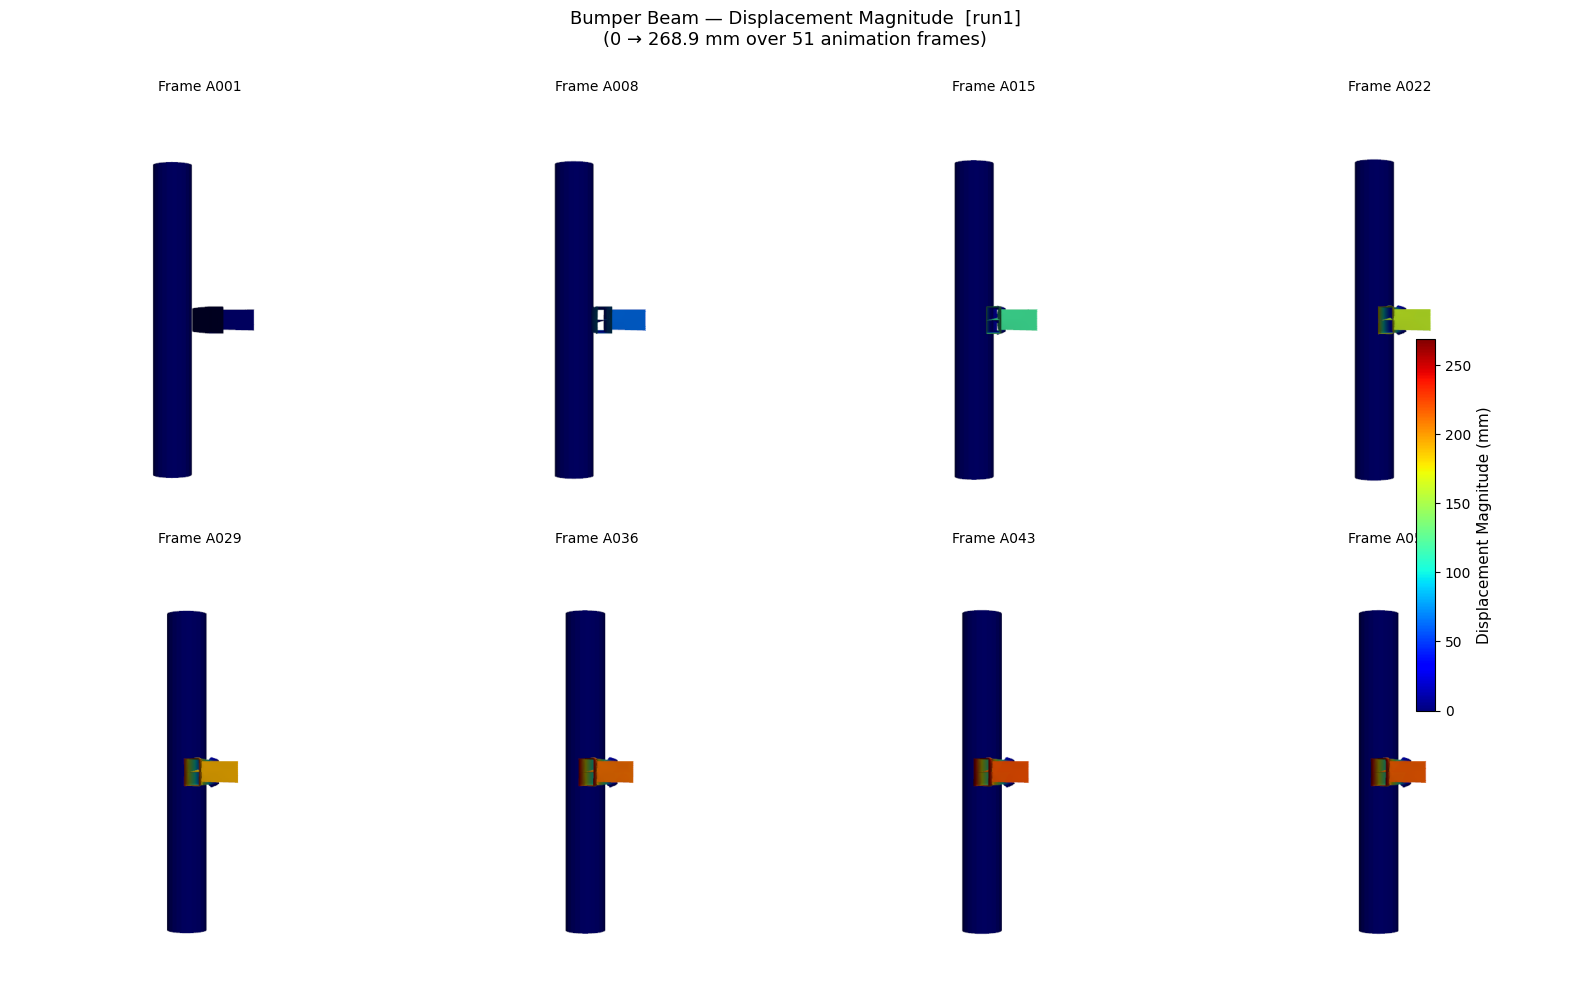

Saved: ../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam/dataset/run1_displacement_grid.png


In [9]:
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path

# ── Pick the run to visualize ────────────────────────────────────────────────
run_dirs = sorted(BB_DATASET_DIR.glob("run*"))
if not run_dirs:
    raise RuntimeError("No run directories found — complete Section 8 first.")

run_dir  = run_dirs[0]                        # visualise run 1
vtk_files = sorted(run_dir.glob("*.vtk"))    # A001.vtk … A051.vtk

if not vtk_files:
    raise RuntimeError(f"No VTK files in {run_dir} — check anim_to_vtk step in Section 8.")

print(f"Run     : {run_dir.name}")
print(f"Frames  : {len(vtk_files)}  ({vtk_files[0].name} … {vtk_files[-1].name})")

# ── Auto-detect displacement field name ─────────────────────────────────────
pv.start_xvfb()                      # headless display (needed on DGX / remote)
sample = pv.read(str(vtk_files[0]))
print("Point-data arrays:", list(sample.point_data.keys()))

disp_key = None
for key in sample.point_data.keys():
    if "disp" in key.lower() or key.upper() in ("U", "D", "DISP"):
        disp_key = key
        break
if disp_key is None and sample.point_data.keys():
    disp_key = list(sample.point_data.keys())[0]

if disp_key is None:
    raise RuntimeError("No point-data arrays found in VTK files.")

print(f"Field   : '{disp_key}'  (will use magnitude)")
print()

# ── Load all frames and compute displacement magnitudes ──────────────────────
meshes = []
mag_min, mag_max = np.inf, -np.inf

for vf in vtk_files:
    mesh = pv.read(str(vf))
    arr  = mesh.point_data[disp_key]
    if arr.ndim == 2:                    # vector (N,3) → compute magnitude
        mag = np.linalg.norm(arr, axis=1)
    else:                                # scalar already
        mag = arr
    mesh.point_data["disp_mag"] = mag
    mag_min = min(mag_min, mag.min())
    mag_max = max(mag_max, mag.max())
    meshes.append(mesh)

print(f"Displacement magnitude range: {mag_min:.2f} – {mag_max:.2f} mm")

# ── Film-strip grid (4 columns × 2 rows = 8 timesteps) ───────────────────────
N_COLS, N_ROWS = 4, 2
N_FRAMES = N_COLS * N_ROWS
indices   = np.linspace(0, len(meshes) - 1, N_FRAMES, dtype=int)

cmap   = cm.get_cmap("jet")
norm   = mcolors.Normalize(vmin=mag_min, vmax=mag_max)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 4, N_ROWS * 5))
fig.suptitle(
    f"Bumper Beam — Displacement Magnitude  [{run_dir.name}]\n"
    f"(0 → {mag_max:.1f} mm over {len(meshes)} animation frames)",
    fontsize=13, y=1.01
)

for ax_idx, frame_idx in enumerate(indices):
    ax   = axes[ax_idx // N_COLS][ax_idx % N_COLS]
    mesh = meshes[frame_idx]

    # Off-screen render with pyvista
    plotter = pv.Plotter(off_screen=True, window_size=(600, 700))
    plotter.add_mesh(
        mesh,
        scalars="disp_mag",
        cmap="jet",
        clim=[mag_min, mag_max],
        show_scalar_bar=False,
        lighting=True,
    )
    plotter.camera_position = "xz"       # front view — rotate 90° from "yz"
    plotter.camera.zoom(1.2)
    img = plotter.screenshot(return_img=True)
    plotter.close()

    # Strip mesh-name prefix: "Bumper_Beam_AP_meshedA023" → "A023"
    stem = vtk_files[frame_idx].stem
    t_label = stem.split("meshed")[-1] if "meshed" in stem else stem
    ax.imshow(img)
    ax.set_title(f"Frame {t_label}", fontsize=10)
    ax.axis("off")

# Shared colour bar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical",
                    fraction=0.015, pad=0.02, shrink=0.8)
cbar.set_label("Displacement Magnitude (mm)", fontsize=11)

plt.tight_layout()
out_png = BB_DATASET_DIR / f"{run_dir.name}_displacement_grid.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")

Rendering 51 frames for GIF ...
  5/51 frames done
  10/51 frames done
  15/51 frames done
  20/51 frames done
  25/51 frames done
  30/51 frames done
  35/51 frames done
  40/51 frames done
  45/51 frames done
  50/51 frames done

Saved animation: ../physicsnemo-openradioss/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam/dataset/run1_displacement.gif


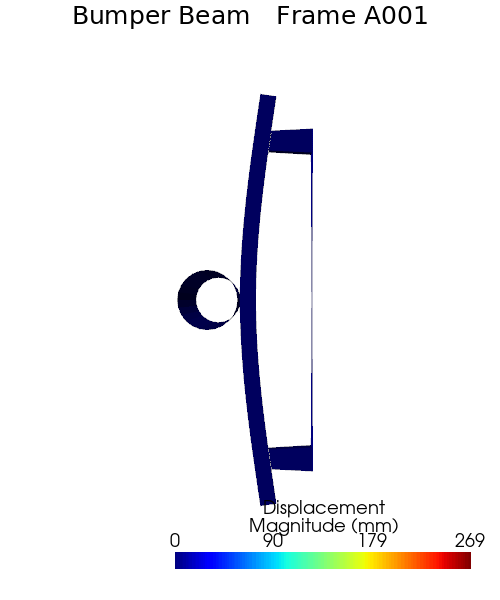

In [14]:
# ── Animated GIF of full deformation sequence ─────────────────────────────────
import warnings, logging
logging.getLogger("pyvista").setLevel(logging.ERROR)  # suppress VTK/Xcursor warnings
import imageio
import numpy as np
import pyvista as pv
from pathlib import Path

gif_path = BB_DATASET_DIR / f"{run_dir.name}_displacement.gif"

# Sub-sample for a reasonable GIF size (every 2nd frame → ~25 frames)
step          = max(1, len(meshes) // 30)
frame_indices = list(range(0, len(meshes), step))

print(f"Rendering {len(frame_indices)} frames for GIF ...")
frames = []

for i, fi in enumerate(frame_indices):
    mesh = meshes[fi]
    plotter = pv.Plotter(off_screen=True, window_size=(500, 600))
    plotter.add_mesh(
        mesh,
        scalars="disp_mag",
        cmap="jet",
        clim=[mag_min, mag_max],
        show_scalar_bar=True,
        scalar_bar_args={
            "title": "Displacement\nMagnitude (mm)",
            "n_labels": 4,
            "fmt": "%.0f",
        },
    )
    plotter.camera_position = "xy"
    plotter.camera.zoom(1.2)
    plotter.add_title(
        f"Bumper Beam  |  Frame {vtk_files[fi].stem.split('meshed')[-1] if 'meshed' in vtk_files[fi].stem else vtk_files[fi].stem}",
        font_size=10
    )
    img = plotter.screenshot(return_img=True)
    plotter.close()
    frames.append(img)
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{len(frame_indices)} frames done")

# Write GIF (duration per frame in seconds)
imageio.mimsave(str(gif_path), frames, fps=8, loop=0)
print(f"\nSaved animation: {gif_path}")

# Display inline in Jupyter
from IPython.display import Image as IPImage, display
display(IPImage(filename=str(gif_path), width=450))

## Section 14 — Drop Test (Optional)

The same 4-step workflow applies to the cell-phone drop test.  
The only differences are:
- Template files: `Cell_Phone_Drop_0000.rad` and `Cell_Phone_Drop_0001.rad`
- Base name for rename: `Cell_Phone_Drop`
- Parameters: Young's modulus scales + wall orientation (not geometry/velocity)
- DoE size: 192 runs (larger, ~42 MB per template)

Run the following if you have the drop test templates:

In [ ]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(SCRIPT_ROOT))

RUN_DROP_TEST = False   # Set True if you have the Cell_Phone_Drop .rad templates

if RUN_DROP_TEST:
    if not DT_STARTER_RAD.exists():
        print(f"Drop test starter template not found: {DT_STARTER_RAD}")
        print("Download from OpenRadioss examples and place in drop_test/templates/")
    else:
        from drop_test.generate_dataset import generate_dataset as dt_generate
        from drop_test.generate_dataset import DEFAULT_EXPERIMENT_SETUP as DT_DOE
        from drop_test.restructure_global_features import convert_global_features as dt_gf
        from common.radioss_runner import RunnerConfig, run_batch
        from common.rename_d3plot import rename_all

        # 1. Generate
        print("Generating drop test dataset (192 runs)...")
        dt_generate(str(DT_STARTER_RAD), str(DT_ENGINE_RAD), str(DT_DATASET_DIR), DT_DOE)

        # 2. Run (set debug_mode=True to test first)
        cfg_dt = RunnerConfig(
            openradioss_root  = str(OPENRADIOSS_ROOT),
            dataset_dir       = str(DT_DATASET_DIR),
            input_base_name   = "Cell_Phone_Drop",
            max_parallel_jobs = 2,
            omp_num_threads   = "8",
            debug_mode        = True,
        )
        run_batch(cfg_dt)

        # 3. Rename
        rename_all(DT_DATASET_DIR, "Cell_Phone_Drop")

        # 4. Global features
        dt_gf(DT_DATASET_DIR / "summary.json",
               DT_DATASET_DIR.parent / "global_features_drop_test.json")
        print("Drop test pipeline complete.")
else:
    print("RUN_DROP_TEST=False — skipping drop test. Set True to enable.")

## Section 15 — Summary and Hand-off to Notebook_Crash0

### What Was Produced

After completing Sections 7–12, your dataset directory contains:

```
data/bumperbeam_openradioss/
├── RAW_DATA/
│   ├── Run0001/
│   │   ├── d3plot              ← LS-DYNA binary (main, all nodes + header)
│   │   ├── d3plot01            ← continuation (timesteps 4–6)
│   │   ├── ...
│   │   └── run0001.k          ← synthetic keyword file (thickness)
│   ├── Run0002/ ...
│   └── Run0135/ ...
└── global_features.json        ← per-run conditioning variables for GeoTransolver
```

### Using This Data in Notebook_Crash0

In `Notebook_Crash0-Data-Preprocessing.ipynb`, change the RAW_DIR path  
and skip the HuggingFace download cell:

```python
# In Notebook_Crash0, Cell 4 (paths):
RAW_DIR = Path("../data/bumperbeam_openradioss")   # ← point here instead of HuggingFace
ZARR_DIR = Path("../data/bumperbeam_zarr_openradioss")

# In Notebook_Crash0, Cell 6 (download): SKIP — data already present
```

The rest of Notebook_Crash0 runs identically:  
the curator ETL reads `RAW_DATA/Run*/d3plot` and produces Zarr stores.

### Complete Pipeline at a Glance

```
[This notebook]
  Step 1: generate_dataset.py    → 135 mutated .rad input decks
  Step 2: run_simulations.py     → 135 × d3plot files (via Starter+Engine+anim2d3plot)
  Step 3: rename_d3plot.py       → d3plot, d3plot01, ... (LS-DYNA naming)
  Step 4: restructure_global.py  → global_features.json (11 conditioning variables)

[Notebook_Crash0]
  ETL curator                    → 135 Zarr stores

[Notebook_Crash1]
  Architecture concepts          → GeoTransolver, GALE, rollout strategies

[Notebook_Crash2]
  Training + inference           → compare one-shot vs time-conditional vs AR-rollout
```

### Troubleshooting

| Symptom | Likely Cause | Fix |
|---------|-------------|-----|
| `starter.log` shows "BAD CARD" | Fixed-width column overflow after scaling | Check scaled value fits 20-char field |
| `engine.log` shows timestep collapse | Over-aggressive thickness reduction (0.7×) | Increase minimum thickness_scale |
| "No animation files (A001) found" | Engine didn't finish | Check `engine.log` for ERROR |
| `d3plot_conv.log` shows `vortex_radioss` error | Wrong stem path (absolute needed) | Update `OPENRADIOSS_ROOT`, reinstall `vortex-radioss` |
| Curator says "No d3plot files found" | Rename step not run | Re-run Section 10 |
| Curator "No cells left after filtering" | `wall_threshold` too aggressive | Increase to 2.0 in Notebook_Crash0 |